In [3]:
import pandas as pd

df = pd.read_csv('/content/100_Unique_QA_Dataset.csv')

df.head()

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


In [4]:
# tokenize
def tokenize(text):
  text = text.lower()
  text = text.replace('?','')
  text = text.replace("'","")
  return text.split()

In [5]:
# vocabulary
vocab = {'<UNK>':0}

In [6]:
def build_vocab(row):
  tokenized_question = tokenize(row['question'])
  tokenized_answer = tokenize(row['answer'])

  merged_tokens = tokenized_question + tokenized_answer

  for token in merged_tokens:

    if token not in vocab:
      vocab[token] = len(vocab)
  return vocab


In [7]:
df.apply(build_vocab, axis=1)

,0
0,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."
1,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."
2,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."
3,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."
4,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."
...,...
85,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."
86,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."
87,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."
88,"{'<UNK>': 0, 'what': 1, 'is': 2, 'the': 3, 'ca..."


In [8]:
len(vocab)

324

In [9]:
# convert words to numerical indices
def text_to_indices(text, vocab):

  indexed_text = []

  for token in tokenize(text):

    if token in vocab:
      indexed_text.append(vocab[token])
    else:
      indexed_text.append(vocab['<UNK>'])

  return indexed_text

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

In [11]:
class QADataset(Dataset):

  def __init__(self, df, vocab):
    self.df = df
    self.vocab = vocab

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, index):

    numerical_question = text_to_indices(self.df.iloc[index]['question'], self.vocab)
    numerical_answer = text_to_indices(self.df.iloc[index]['answer'], self.vocab)

    return torch.tensor(numerical_question), torch.tensor(numerical_answer)

In [12]:
dataset = QADataset(df, vocab)

In [13]:
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

In [14]:
import torch.nn as nn

In [15]:
class SimpleRNN(nn.Module):

  def __init__(self, vocab_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim=50)
    self.rnn = nn.RNN(50, 64, batch_first=True)
    self.fc = nn.Linear(64, vocab_size)

  def forward(self, question):
    embedded_question = self.embedding(question)
    hidden, final = self.rnn(embedded_question)
    output = self.fc(final.squeeze(0))

    return output

In [16]:
x = nn.Embedding(324, embedding_dim=50)
y = nn.RNN(50, 64, batch_first=True)
z = nn.Linear(64, 324)

a = dataset[0][0].reshape(1,6)
print("shape of a:", a.shape)
b = x(a)
print("shape of b:", b.shape)
c, d = y(b)
print("shape of c:", c.shape)
print("shape of d:", d.shape)

e = z(d.squeeze(0))

print("shape of e:", e.shape)

shape of a: torch.Size([1, 6])
shape of b: torch.Size([1, 6, 50])
shape of c: torch.Size([1, 6, 64])
shape of d: torch.Size([1, 1, 64])
shape of e: torch.Size([1, 324])


In [25]:
learning_rate = 0.001
epochs = 35

In [26]:
model = SimpleRNN(len(vocab))

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [28]:

loss_history = []

for epoch in range(epochs):
  total_loss = 0

  for question, answer in dataloader:
    optimizer.zero_grad()
    output = model(question)
    loss = criterion(output, answer[0])
    loss.backward()
    optimizer.step()
    total_loss = total_loss + loss.item()

  loss_history.append(total_loss)
  print(f"Epoch: {epoch+1}, Loss: {total_loss:4f}")


Epoch: 1, Loss: 518.997409
Epoch: 2, Loss: 450.631788
Epoch: 3, Loss: 372.548045
Epoch: 4, Loss: 308.855193
Epoch: 5, Loss: 255.549430
Epoch: 6, Loss: 206.562239
Epoch: 7, Loss: 161.900238
Epoch: 8, Loss: 124.269344
Epoch: 9, Loss: 93.832729
Epoch: 10, Loss: 71.406039
Epoch: 11, Loss: 54.228219
Epoch: 12, Loss: 42.303038
Epoch: 13, Loss: 33.293223
Epoch: 14, Loss: 26.694318
Epoch: 15, Loss: 21.927277
Epoch: 16, Loss: 18.214267
Epoch: 17, Loss: 15.388611
Epoch: 18, Loss: 13.104380
Epoch: 19, Loss: 11.276340
Epoch: 20, Loss: 9.745644
Epoch: 21, Loss: 8.583871
Epoch: 22, Loss: 7.592948
Epoch: 23, Loss: 6.791001
Epoch: 24, Loss: 6.059592
Epoch: 25, Loss: 5.439876
Epoch: 26, Loss: 4.923559
Epoch: 27, Loss: 4.471954
Epoch: 28, Loss: 4.087056
Epoch: 29, Loss: 3.735441
Epoch: 30, Loss: 3.433492
Epoch: 31, Loss: 3.152796
Epoch: 32, Loss: 2.908216
Epoch: 33, Loss: 2.687230
Epoch: 34, Loss: 2.489495
Epoch: 35, Loss: 2.312816


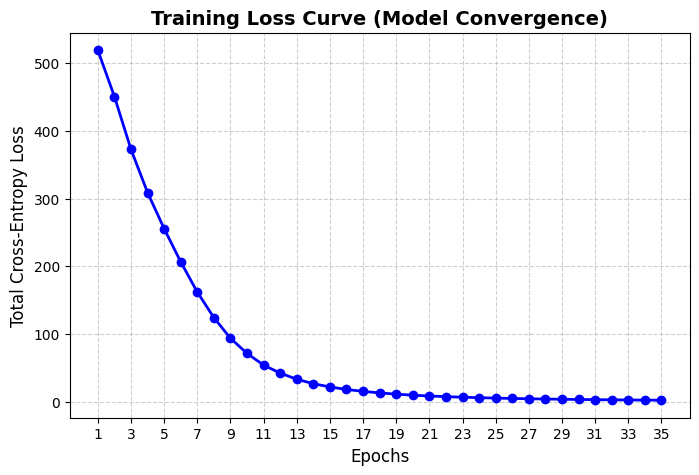

In [32]:
import matplotlib.pyplot as plt

# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Training Loss Curve (Model Convergence)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Total Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, epochs + 1, 2)) # Adjust tick spacing based on epoch count
plt.show()


In [29]:
def predict(model, question, threshold=0.5):
    model.eval()

    numerical_question = text_to_indices(question, vocab)
    question_tensor = torch.tensor(numerical_question).unsqueeze(0)

    with torch.no_grad():
        output = model(question_tensor)

    probs = torch.nn.functional.softmax(output, dim=1)
    value, index = torch.max(probs, dim=1)


    if value.item() < threshold:
        print("I don't know")
    else:
        print(list(vocab.keys())[index.item()])


In [35]:
predict(model, "What is the largest planet in solar system?")

jupiter
